In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile

# CHANGE THIS to match your actual zip file path from Step 2
ZIP_PATH = '/content/drive/MyDrive/gesture_subset.zip'

# Unzip to Colab's LOCAL storage (much faster than Drive)
EXTRACT_PATH = '/content/dataset'

print("Unzipping... (this may take a few minutes for 2.66GB)")
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)
print("Done!")

# Check what got extracted
for item in os.listdir(EXTRACT_PATH):
    print(item)


Unzipping... (this may take a few minutes for 2.66GB)
Done!
gesture_subset


In [4]:
import os

# The folder structure might be nested — let's find the gesture folders
EXTRACT_PATH = '/content/dataset'

def find_gesture_folders(path, depth=0):
    """Recursively look for the gesture folders."""
    if depth > 3:
        return
    items = sorted(os.listdir(path))
    for item in items:
        full_path = os.path.join(path, item)
        if os.path.isdir(full_path):
            # Check if this looks like a gesture folder
            sub_items = os.listdir(full_path)
            has_avi = any(f.endswith('.avi') for f in sub_items)
            if has_avi:
                print(f"  GESTURE FOLDER: {full_path} ({len(sub_items)} files)")
            else:
                print(f"  Folder: {full_path}")
                find_gesture_folders(full_path, depth + 1)

print("Looking for gesture folders...\n")
find_gesture_folders(EXTRACT_PATH)

Looking for gesture folders...

  Folder: /content/dataset/gesture_subset
  GESTURE FOLDER: /content/dataset/gesture_subset/background (7 files)
  GESTURE FOLDER: /content/dataset/gesture_subset/backward (8 files)
  GESTURE FOLDER: /content/dataset/gesture_subset/down (8 files)
  GESTURE FOLDER: /content/dataset/gesture_subset/forward (8 files)
  GESTURE FOLDER: /content/dataset/gesture_subset/left (7 files)
  GESTURE FOLDER: /content/dataset/gesture_subset/pitchdown (8 files)
  GESTURE FOLDER: /content/dataset/gesture_subset/pitchup (8 files)
  GESTURE FOLDER: /content/dataset/gesture_subset/right (8 files)
  GESTURE FOLDER: /content/dataset/gesture_subset/up (8 files)
  GESTURE FOLDER: /content/dataset/gesture_subset/yawleft (7 files)
  GESTURE FOLDER: /content/dataset/gesture_subset/yawright (7 files)


In [5]:
import cv2
import os

DATASET_PATH = '/content/dataset/gesture_subset'
FRAMES_DIR = '/content/frames'
FRAMES_PER_VIDEO = 30

gesture_classes = sorted([
    f for f in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, f))
])

print("Extracting frames from videos...")

for gesture in gesture_classes:
    video_folder = os.path.join(DATASET_PATH, gesture)
    frames_folder = os.path.join(FRAMES_DIR, gesture)
    os.makedirs(frames_folder, exist_ok=True)

    video_files = [f for f in os.listdir(video_folder) if f.lower().endswith('.avi')]

    for video_file in video_files:
        video_path = os.path.join(video_folder, video_file)
        cap = cv2.VideoCapture(video_path)

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames == 0:
            print(f"  WARNING: {video_file} has 0 frames, skipping")
            continue

        num_to_extract = min(FRAMES_PER_VIDEO, total_frames)
        frame_indices = set([
            int(i * total_frames / num_to_extract)
            for i in range(num_to_extract)
        ])

        frame_count = 0
        saved_count = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break
            if frame_count in frame_indices:
                video_name = video_file.replace('.avi', '')
                frame_filename = f"{video_name}_frame{saved_count:03d}.jpg"
                save_path = os.path.join(frames_folder, frame_filename)
                cv2.imwrite(save_path, frame)
                saved_count += 1
            frame_count += 1

        cap.release()

    frame_total = len(os.listdir(frames_folder))
    print(f"  {gesture}: {len(video_files)} videos -> {frame_total} frames")

Extracting frames from videos...
  background: 7 videos -> 210 frames
  backward: 8 videos -> 240 frames
  down: 8 videos -> 240 frames
  forward: 8 videos -> 240 frames
  left: 7 videos -> 210 frames
  pitchdown: 8 videos -> 240 frames
  pitchup: 8 videos -> 240 frames
  right: 8 videos -> 240 frames
  up: 8 videos -> 240 frames
  yawleft: 7 videos -> 210 frames
  yawright: 7 videos -> 210 frames


In [1]:
!pip install protobuf==5.29.5
!pip install tensorflow==2.19.0
!pip install mediapipe==0.10.21

  Using cached protobuf-5.29.5-cp38-abi3-manylinux2014_x86_64.whl.metadata (592 bytes)
Using cached protobuf-5.29.5-cp38-abi3-manylinux2014_x86_64.whl (319 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.9
    Uninstalling protobuf-4.25.9:
      Successfully uninstalled protobuf-4.25.9
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires jaxlib>=0.1.51, which is not installed.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.0 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.0 which is incompatible.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.19.0 which is incompatible.


  Using cached mediapipe-0.10.21-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.7 kB)
  Using cached jaxlib-0.10.1-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (1.3 kB)
  Using cached protobuf-4.25.9-cp37-abi3-manylinux2014_x86_64.whl.metadata (541 bytes)
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
  Using cached jax-0.10.1-py3-none-any.whl.metadata (13 kB)
  Using cached jax-0.10.0-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.10.0-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (1.3 kB)
  Using cached jax-0.9.2-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.9.2-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (1.3 kB)
  Using cached jax-0.9.1-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.9.1-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (1.3 kB)
  Using cached jax-0.9.0.1-py3-none-any.whl.metadata (13 kB)
  Using cached jaxlib-0.9.0.1-cp312-cp312-manyl

In [1]:
import google.protobuf
print("protobuf:", google.protobuf.__version__)

import mediapipe as mp
print("mediapipe:", mp.__version__)

mp_hands = mp.solutions.hands
print("OK!")


protobuf: 4.25.9
mediapipe: 0.10.21
OK!


In [2]:
import mediapipe as mp
import cv2
import numpy as np
import os

mp_hands = mp.solutions.hands
hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5
)

FRAMES_DIR = '/content/frames'

gesture_classes = sorted([
    f for f in os.listdir(FRAMES_DIR)
    if os.path.isdir(os.path.join(FRAMES_DIR, f))
])

all_landmarks = []
all_labels = []
skipped = 0

print("Extracting hand landmarks...")

for gesture in gesture_classes:
    frames_folder = os.path.join(FRAMES_DIR, gesture)
    frame_files = sorted([f for f in os.listdir(frames_folder) if f.endswith('.jpg')])
    detected = 0

    for frame_file in frame_files:
        frame_path = os.path.join(frames_folder, frame_file)
        image = cv2.imread(frame_path)
        if image is None:
            continue

        rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        results = hands.process(rgb)

        if results.multi_hand_landmarks:
            landmarks = results.multi_hand_landmarks[0]
            coords = []
            for lm in landmarks.landmark:
                coords.append(lm.x)
                coords.append(lm.y)
                coords.append(lm.z)

            all_landmarks.append(coords)
            all_labels.append(gesture)
            detected += 1
        else:
            skipped += 1

    print(f"  {gesture}: {detected} hands detected (out of {len(frame_files)})")

hands.close()

X = np.array(all_landmarks)
y = np.array(all_labels)

print(f"\nTotal samples: {X.shape[0]}")
print(f"Skipped (no hand): {skipped}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Extracting hand landmarks...
  background: 178 hands detected (out of 210)
  backward: 218 hands detected (out of 240)
  down: 236 hands detected (out of 240)
  forward: 182 hands detected (out of 240)
  left: 202 hands detected (out of 210)
  pitchdown: 199 hands detected (out of 240)
  pitchup: 203 hands detected (out of 240)
  right: 235 hands detected (out of 240)
  up: 238 hands detected (out of 240)
  yawleft: 172 hands detected (out of 210)
  yawright: 134 hands detected (out of 210)

Total samples: 2197
Skipped (no hand): 323
X shape: (2197, 63)
y shape: (2197,)


In [3]:
import os
SAVE_PATH = '/content/drive/MyDrive/gesture_data'
os.makedirs(SAVE_PATH, exist_ok=True)

np.save(os.path.join(SAVE_PATH, 'X_landmarks.npy'), X)
np.save(os.path.join(SAVE_PATH, 'y_labels.npy'), y)

print(f"Saved to {SAVE_PATH}")


Saved to /content/drive/MyDrive/gesture_data


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pickle

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Label mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {i} = {label}")

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"\nTrain: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")

for name, data in [('X_train', X_train), ('y_train', y_train),
                    ('X_val', X_val), ('y_val', y_val),
                    ('X_test', X_test), ('y_test', y_test)]:
    np.save(os.path.join(SAVE_PATH, f'{name}.npy'), data)

with open(os.path.join(SAVE_PATH, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(label_encoder, f)

print("Split and saved!")

Label mapping:
  0 = background
  1 = backward
  2 = down
  3 = forward
  4 = left
  5 = pitchdown
  6 = pitchup
  7 = right
  8 = up
  9 = yawleft
  10 = yawright

Train: 1537 samples
Val:   330 samples
Test:  330 samples
Split and saved!


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import os

# Load data
SAVE_PATH = '/content/drive/MyDrive/gesture_data'
X_train = np.load(os.path.join(SAVE_PATH, 'X_train.npy'))
y_train = np.load(os.path.join(SAVE_PATH, 'y_train.npy'))
X_val = np.load(os.path.join(SAVE_PATH, 'X_val.npy'))
y_val = np.load(os.path.join(SAVE_PATH, 'y_val.npy'))

print(f"Train: {X_train.shape}, Val: {X_val.shape}")

# Build model
model = models.Sequential([
    # Input: 63 values (21 landmarks x 3 coords)
    layers.Input(shape=(63,)),

    # Reshape to (21, 3) — treat each landmark as a "step" with 3 features
    layers.Reshape((21, 3)),

    # 1D CNN layers — extract patterns between neighboring landmarks
    layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv1D(256, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),

    # GRU layer — learn sequential relationships between landmarks
    layers.GRU(128, return_sequences=False),

    # Dense layers — final classification
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    # Output: 11 gesture classes
    layers.Dense(11, activation='softmax'),
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Train: (1537, 63), Val: (330, 63)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 21, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 21, 64)         │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 21, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 21, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 21, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 21, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 341,259 (1.30 MB)

 Trainable params: 340,363 (1.30 MB)

 Non-trainable params: 896 (3.50 KB)

In [6]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=15,                # Stop if no improvement for 15 epochs
            restore_best_weights=True   # Go back to the best version
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            factor=0.5,    # Cut learning rate in half
            patience=7     # if no improvement for 7 epochs
        ),
    ]
)

Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.2362 - loss: 2.1556 - val_accuracy: 0.1545 - val_loss: 2.3877 - learning_rate: 0.0010
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.3318 - loss: 1.9050 - val_accuracy: 0.1333 - val_loss: 2.4453 - learning_rate: 0.0010
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.4086 - loss: 1.6994 - val_accuracy: 0.1212 - val_loss: 2.4341 - learning_rate: 0.0010
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.4665 - loss: 1.5381 - val_accuracy: 0.1909 - val_loss: 2.4206 - learning_rate: 0.0010
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.5394 - loss: 1.3093 - val_accuracy: 0.1273 - val_loss: 2.9415 - learning_rate: 0.0010
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.5817 - loss: 1.1516 - val_accuracy: 0.1182 - val_loss: 3.0250 - learning_rate: 0.0010
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.6454 - loss: 1.0148 -

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.9030 - loss: 0.2506



Test Accuracy: 90.30%
Model saved!


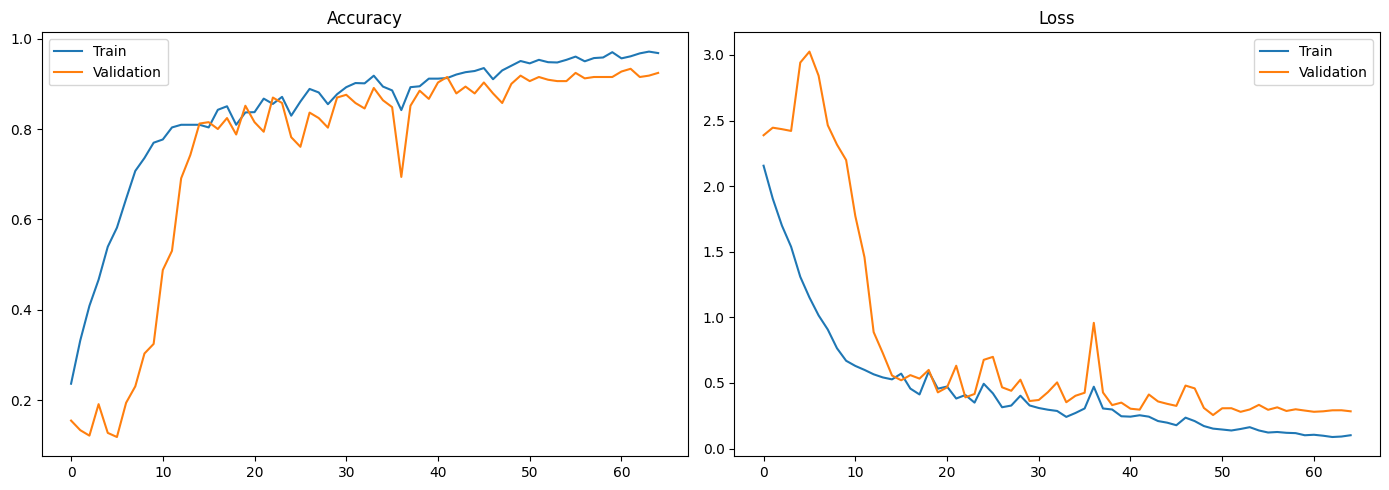

In [7]:
# Test accuracy
X_test = np.load(os.path.join(SAVE_PATH, 'X_test.npy'))
y_test = np.load(os.path.join(SAVE_PATH, 'y_test.npy'))

test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")

# Save model to Drive
model.save(os.path.join(SAVE_PATH, 'gesture_model.h5'))
print("Model saved!")

# Plot training history
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 199ms/step
Classification Report:
              precision    recall  f1-score   support

  background       0.91      0.81      0.86        26
    backward       0.84      1.00      0.91        32
        down       1.00      1.00      1.00        36
     forward       0.90      1.00      0.95        28
        left       0.88      0.97      0.92        31
   pitchdown       1.00      0.83      0.91        30
     pitchup       1.00      1.00      1.00        30
       right       1.00      1.00      1.00        36
          up       0.97      1.00      0.99        35
     yawleft       0.73      0.62      0.67        26
    yawright       0.47      0.45      0.46        20

    accuracy                           0.90       330
   macro avg       0.88      0.88      0.88       330
weighted avg       0.90      0.90      0.90       330



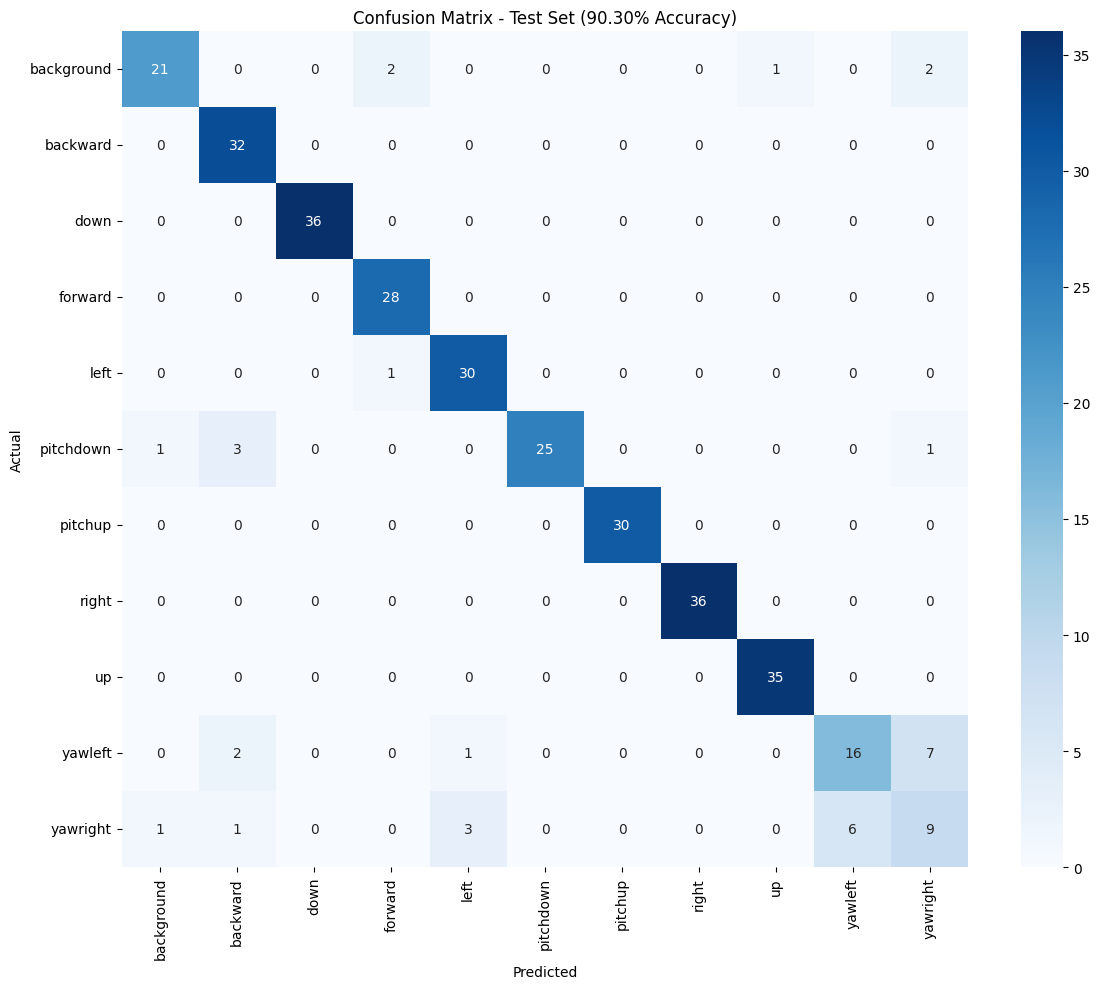

In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Load label encoder
with open(os.path.join(SAVE_PATH, 'label_encoder.pkl'), 'rb') as f:
    label_encoder = pickle.load(f)

# Predict on test set
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_classes,
      target_names=label_encoder.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Test Set (90.30% Accuracy)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'confusion_matrix.png'), dpi=150)
plt.show()